# House Price Prediction — India Property Listings

**End-to-end regression notebook:** load & inspect → EDA → cleaning & feature engineering →
pipeline & training (≥2 models) → evaluation → export a deployable model.

**Dataset:** [House Price by Juhi Bhojani](https://www.kaggle.com/datasets/juhibhojani/house-price)
(~187k Indian property listings, file `house_prices.csv`).

**Target:** the sale price in rupees, parsed from the free-text `Amount(in rupees)` column
(e.g. `"42 Lac"` → 4,200,000).


## 2.1 Load & Inspect

We load the raw CSV and look at its shape, column dtypes, and missingness **before** touching anything.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# Robust path: works whether the CSV is in notebooks/data/ (canonical) or the repo root.
CANDIDATES = [Path("data/house_prices.csv"), Path("../house_prices.csv"), Path("house_prices.csv")]
csv_path = next((p for p in CANDIDATES if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "house_prices.csv not found. Download it from Kaggle into notebooks/data/ "
        "(see README) — e.g. `kaggle datasets download -d juhibhojani/house-price "
        "-p notebooks/data --unzip`."
    )
df = pd.read_csv(csv_path)
print("Loaded", csv_path, "->", df.shape)
df.head()

Loaded data\house_prices.csv -> (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Percentage missing per column
(df.isna().mean() * 100).round(1).sort_values(ascending=False)

Plot Area            100.0
Dimensions           100.0
Society               58.5
Super Area            57.4
Car Parking           55.1
overlooking           43.4
Carpet Area           43.0
facing                37.5
Ownership             34.9
Balcony               26.1
Price (in rupees)      9.4
Floor                  3.8
Description            1.6
Furnishing             1.5
Bathroom               0.4
Status                 0.3
Index                  0.0
Amount(in rupees)      0.0
Title                  0.0
Transaction            0.0
location               0.0
dtype: float64

### What we see

- **Rows / columns:** ~187k rows × 21 columns.
- **Numeric vs text:** only `Index`, `Price (in rupees)`, `Dimensions`, `Plot Area` are numeric dtypes.
  Everything price/area/floor/room-related is stored as **text** and must be parsed.
- **Most missing:** `Plot Area` and `Dimensions` are **100% empty**; `Society` (58%), `Super Area` (57%),
  `Car Parking` (55%), `overlooking` (43%), `Carpet Area` (43%), `facing` (38%) are heavily missing.
- **Trap — the numeric `Price (in rupees)` column is NOT the price.** Its values are tiny
  (mean ≈ 7,600) and equal roughly `Amount ÷ area`, i.e. a **per-unit rate**. Using it as the target
  would be leakage, so we drop it and parse the real price from the text `Amount(in rupees)` column.
- **Trap — `Status` is single-valued** (all "Ready to Move") so it carries no signal → drop.


In [5]:
# Evidence: the numeric "Price (in rupees)" column is a rate, not the sale price.
display(df["Price (in rupees)"].describe())
print("\nStatus value counts:")
print(df["Status"].value_counts(dropna=False))

count    1.698660e+05
mean     7.583772e+03
std      2.724171e+04
min      0.000000e+00
25%      4.297000e+03
50%      6.034000e+03
75%      9.450000e+03
max      6.700000e+06
Name: Price (in rupees), dtype: float64


Status value counts:
Status
Ready to Move    186916
NaN                 615
Name: count, dtype: int64


## 2.2 Exploratory Data Analysis

The target is stored as text, so we define our parsers first and derive a few numeric columns
(`price`, `area_sqft`, `bhk`) **on a copy** purely to explore them. Full cleaning happens in §2.3.


In [6]:
import re

def parse_amount(x):
    """'42 Lac' -> 4_200_000 ; '1.40 Cr' -> 14_000_000 ; 'Call for Price' -> NaN.
    1 Lac = 1e5 rupees, 1 Cr = 1e7 rupees."""
    if not isinstance(x, str):
        return np.nan
    x = x.strip().lower().replace(",", "")
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x)
    except ValueError:
        return np.nan

def parse_area(x):
    """'1200 sqft' -> 1200.0 ; '140 sqm' -> ~1507 sqft (1 sqm = 10.764 sqft)."""
    if not isinstance(x, str):
        return np.nan
    m = re.search(r"([\d.]+)", x.replace(",", ""))
    if not m:
        return np.nan
    val = float(m.group(1))
    if "sqm" in x.lower() or "sq.m" in x.lower():
        val *= 10.764
    return val

def parse_bhk(title):
    """Extract bedroom count from the listing Title, e.g. '2 BHK ...' -> 2."""
    if not isinstance(title, str):
        return np.nan
    m = re.search(r"(\d+)\s*BHK", title, re.I)
    return float(m.group(1)) if m else np.nan

eda = df.copy()
eda["price"] = eda["Amount(in rupees)"].apply(parse_amount)
# Carpet and Super area are complementary; coalesce to maximise coverage.
eda["area_sqft"] = eda["Carpet Area"].apply(parse_area).fillna(eda["Super Area"].apply(parse_area))
eda["bhk"] = eda["Title"].apply(parse_bhk)

print("Rows with a usable price:", eda["price"].notna().sum(),
      f'({eda["price"].notna().mean():.1%})')
print("Rows with an area (carpet OR super):", eda["area_sqft"].notna().sum(),
      f'({eda["area_sqft"].notna().mean():.1%})')
print("Rows with a BHK from Title:", eda["bhk"].notna().sum(),
      f'({eda["bhk"].notna().mean():.1%})')

Rows with a usable price: 177847 (94.8%)
Rows with an area (carpet OR super): 186704 (99.6%)
Rows with a BHK from Title: 186610 (99.5%)


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

**Plot 1 — Target distribution (log scale).** Price spans several orders of magnitude, so we
expect a heavy right skew and use a log x-axis.

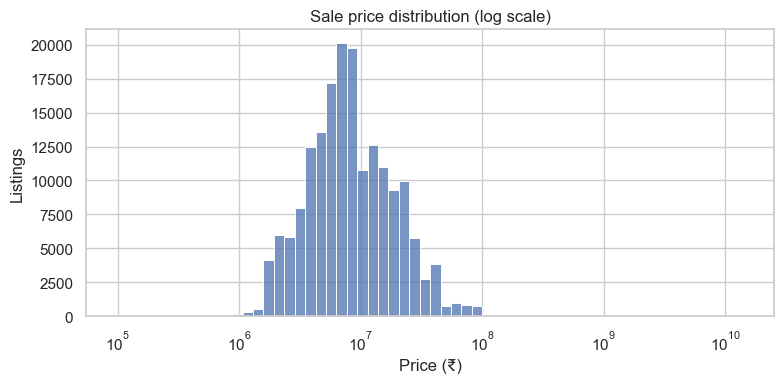

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(eda["price"].dropna(), log_scale=True, bins=60, ax=ax)
ax.set(title="Sale price distribution (log scale)", xlabel="Price (₹)", ylabel="Listings")
plt.tight_layout(); plt.show()

*Comment:* on a log axis the price is roughly bell-shaped and centered around ₹70–90 Lac, confirming
a strong right skew on the raw scale. This is why we later **train on `log1p(price)`** — it stabilises
the target and lets the models fit the multiplicative nature of prices.

**Plot 2 — Price vs. area.** Bigger homes should cost more; we sample 5,000 points and use log–log
axes to see the relationship without the mega-outliers dominating.

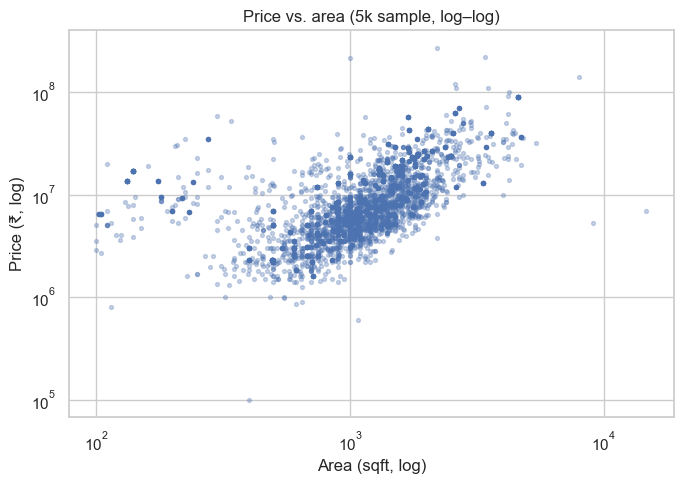

In [9]:
samp = eda.dropna(subset=["price", "area_sqft"])
samp = samp[(samp["area_sqft"].between(100, 20000))].sample(5000, random_state=42)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(samp["area_sqft"], samp["price"], s=8, alpha=0.3)
ax.set(xscale="log", yscale="log", xlabel="Area (sqft, log)", ylabel="Price (₹, log)",
       title="Price vs. area (5k sample, log–log)")
plt.tight_layout(); plt.show()

*Comment:* a clear positive log–log trend — larger carpet/super area maps to higher price — which
makes `area_sqft` our single strongest numeric predictor. The vertical spread at any given area is the
part explained by **location, BHK, furnishing** etc.

**Plot 3 — Average price by top-15 locations.** Location is the other big driver.

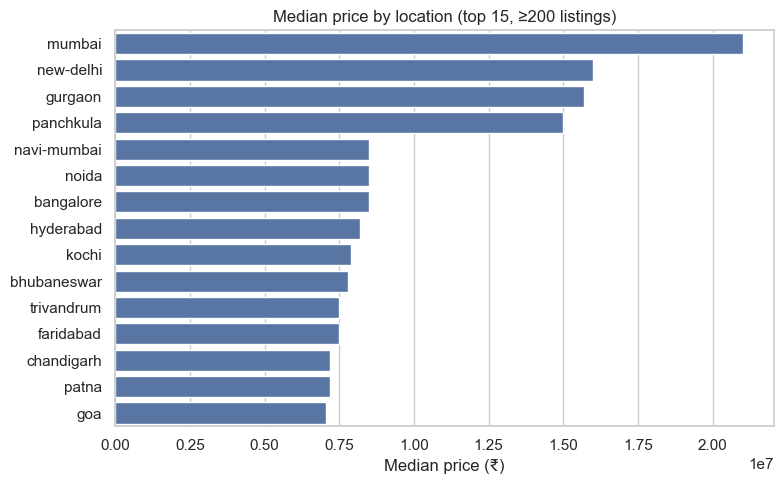

In [10]:
top15 = eda.groupby("location")["price"].median().sort_values(ascending=False)
top15 = top15[eda["location"].value_counts()[top15.index] >= 200].head(15)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top15.values, y=top15.index, ax=ax, color="#4C72B0")
ax.set(title="Median price by location (top 15, ≥200 listings)", xlabel="Median price (₹)", ylabel="")
plt.tight_layout(); plt.show()

*Comment:* median prices differ by several-fold across cities (metro hubs like Mumbai/Gurgaon/Bangalore
at the top), so `location` clearly belongs in the model. We use **median** (not mean) because a few luxury
listings would otherwise distort the average.

**Plot 4 — Price by furnishing status (box plot).**

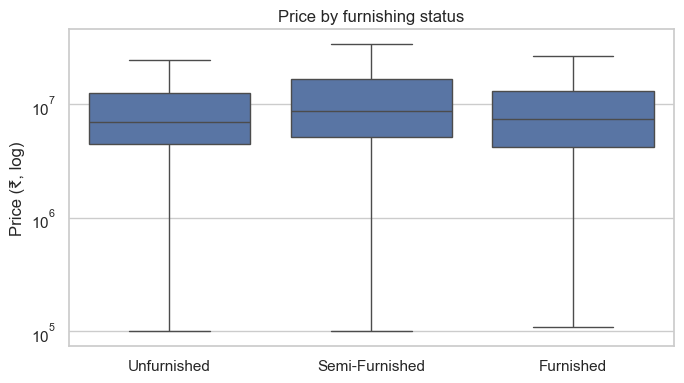

In [11]:
order = ["Unfurnished", "Semi-Furnished", "Furnished"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=eda[eda["Furnishing"].isin(order)], x="Furnishing", y="price",
            order=order, showfliers=False, ax=ax)
ax.set(yscale="log", title="Price by furnishing status", xlabel="", ylabel="Price (₹, log)")
plt.tight_layout(); plt.show()

*Comment:* furnished homes skew a little higher, but the boxes overlap heavily — furnishing is a
**weak** predictor on its own compared with area and location. We keep it, but don't expect much from it.

**Plot 5 (bonus) — Price by BHK (bedrooms).**

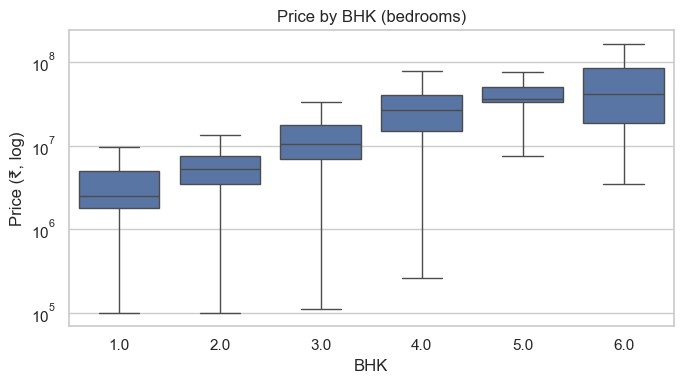

In [12]:
bh = eda[eda["bhk"].between(1, 6)]
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=bh, x="bhk", y="price", showfliers=False, ax=ax)
ax.set(yscale="log", title="Price by BHK (bedrooms)", xlabel="BHK", ylabel="Price (₹, log)")
plt.tight_layout(); plt.show()

*Comment:* price rises monotonically with BHK — a strong, clean signal. Extracting `bhk` from the
`Title` text (99.5% coverage) before dropping the text columns is one of our most valuable features.

**Plot 6 (bonus) — Correlation of numeric drivers (on log price).**

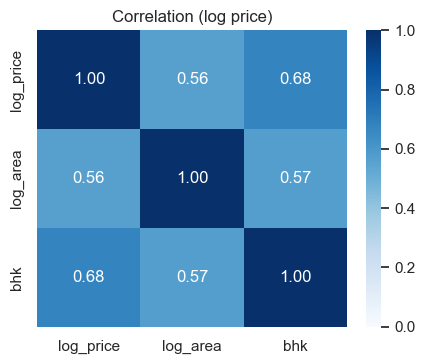

In [13]:
corr_df = eda.assign(log_price=np.log1p(eda["price"]),
                     log_area=np.log1p(eda["area_sqft"]))[["log_price", "log_area", "bhk"]].dropna()
fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set(title="Correlation (log price)")
plt.tight_layout(); plt.show()

*Comment:* log-area and BHK are both strongly correlated with log-price (and with each other),
confirming the two dominant, partly-overlapping drivers of price.

## 2.3 Cleaning & Feature Engineering

This dataset is messy on purpose. We now build a clean modeling frame from scratch, handling every
problem column. Remaining parsers (`floor`, integer counts) are defined here.


In [14]:
def parse_floor(x):
    """'3 out of 11' -> 3 ; 'Ground out of 4' -> 0 ; 'Basement ...' -> -1."""
    if not isinstance(x, str):
        return np.nan
    first = x.strip().lower().split("out of")[0].strip()
    if "ground" in first:
        return 0.0
    if "basement" in first:
        return -1.0
    m = re.search(r"(\d+)", first)
    return float(m.group(1)) if m else np.nan

def parse_count(x):
    """'2' -> 2 ; '> 10' -> 11 ; '1 Covered,' -> 1 ; NaN -> NaN."""
    if pd.isna(x):
        return np.nan
    s = str(x)
    m = re.search(r"(\d+)", s)
    if not m:
        return np.nan
    return float(m.group(1)) + 1 if ">" in s else float(m.group(1))

In [15]:
clean = df.copy()

# 1) Target: parse price text, drop unusable ("Call for Price") and non-positive.
clean["price"] = clean["Amount(in rupees)"].apply(parse_amount)
clean = clean.dropna(subset=["price"])
clean = clean[clean["price"] > 0]

# 2) Area: coalesce carpet (preferred) with super area, normalised to sqft.
clean["area_sqft"] = (clean["Carpet Area"].apply(parse_area)
                      .fillna(clean["Super Area"].apply(parse_area)))

# 3) Floor number, 4) room/parking counts, + BHK from Title.
clean["floor_num"]   = clean["Floor"].apply(parse_floor)
clean["bathroom"]    = clean["Bathroom"].apply(parse_count)
clean["balcony"]     = clean["Balcony"].apply(parse_count)
clean["car_parking"] = clean["Car Parking"].apply(parse_count)
clean["bhk"]         = clean["Title"].apply(parse_bhk)

# 5) High-cardinality location -> keep top-50, group the rest as "other".
TOP_N = 50
top_locations = clean["location"].value_counts().head(TOP_N).index
clean["location_grouped"] = clean["location"].where(clean["location"].isin(top_locations), "other")

print("After parsing price:", clean.shape)

After parsing price: (177847, 29)


In [16]:
# area_sqft is a core feature and needed for the outlier filter -> require it.
before = len(clean)
clean = clean.dropna(subset=["area_sqft"])
clean = clean[clean["area_sqft"] > 0]
print(f"Dropped {before - len(clean)} rows with no usable area (only ~0.05%).")

# 7) Remove outliers on price-per-sqft (1st/99th pct) and implausible areas.
clean["ppsf"] = clean["price"] / clean["area_sqft"]
lo, hi = clean["ppsf"].quantile([0.01, 0.99])
clean = clean[(clean["ppsf"] >= lo) & (clean["ppsf"] <= hi)]
clean = clean[clean["area_sqft"].between(100, 20000)]
print(f"Price-per-sqft kept to ₹{lo:,.0f}..₹{hi:,.0f}/sqft.")
print("Final modeling frame:", clean.shape)
print(f"Price range: ₹{clean['price'].min():,.0f} .. ₹{clean['price'].max():,.0f}"
      f"  (median ₹{clean['price'].median():,.0f})")

Dropped 90 rows with no usable area (only ~0.05%).


Price-per-sqft kept to ₹2,285..₹101,504/sqft.
Final modeling frame: (171597, 30)
Price range: ₹360,000 .. ₹800,000,000  (median ₹7,900,000)


### Cleaning decisions (and why)

| Problem | Decision |
|---|---|
| `Amount(in rupees)` is text (`"42 Lac"`, `"Call for Price"`) | Parse Lac/Cr → ₹; drop unusable rows. **This is the target.** |
| `Price (in rupees)` numeric column | **Dropped** — it's a per-area rate, not the sale price (leakage). |
| `Carpet Area` (43% missing) / `Super Area` (57% missing) | Parse to sqft and **coalesce** — only ~0.05% of rows lack both. |
| `Floor` (`"3 out of 11"`, `"Ground"`) | Extract floor number; Ground→0, Basement→-1. |
| `Bathroom` / `Balcony` / `Car Parking` (`"> 10"`, `"1 Covered,"`) | Extract integer; imputed later inside the pipeline. |
| `Title` free text | **Feature-engineered** `bhk` (bedrooms) — 99.5% coverage — then dropped. |
| `location` (81 cities) | Keep top-50, group rest as `"other"` for stable one-hot encoding. |
| `Plot Area`, `Dimensions` (100% empty), `Status` (single value), `Society`/`Description` | **Dropped** — no signal or unusable. |
| Absurd price-per-sqft | Trimmed to the 1st–99th percentile. |


## 2.4 Build a Pipeline & Train

All preprocessing lives **inside** a scikit-learn `Pipeline` + `ColumnTransformer`, so the exported
`.pkl` takes raw feature values and handles imputation/scaling/encoding itself — the backend stays trivial.

Because price is skewed, we wrap regressors in a `TransformedTargetRegressor` that trains on
`log1p(price)` and inverts with `expm1` at prediction time. We compare **three** models:
a `LinearRegression` baseline (raw target), a constrained `RandomForest`, and `HistGradientBoosting`.


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

numeric_features = ["area_sqft", "floor_num", "bathroom", "balcony", "car_parking", "bhk"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     categorical_features),
])

X = clean[numeric_features + categorical_features]
y = clean["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (137277, 11)  Test: (34320, 11)


In [18]:
def build(regressor, log_target=True):
    pipe = Pipeline([("prep", preprocessor), ("reg", regressor)])
    if log_target:
        return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
    return pipe

models = {
    "LinearRegression (baseline)": build(LinearRegression(), log_target=False),
    "RandomForest (log target)": build(RandomForestRegressor(
        n_estimators=150, max_features=0.5, min_samples_leaf=4,
        n_jobs=-1, random_state=42)),
    "HistGradientBoosting (log target)": build(HistGradientBoostingRegressor(
        max_iter=500, random_state=42)),
}
for name in models:
    print("-", name)

- LinearRegression (baseline)
- RandomForest (log target)
- HistGradientBoosting (log target)


## 2.5 Evaluate

We fit each model and report **MAE / RMSE / R² on the held-out test set** (never the training set).


In [19]:
import joblib, os

rows, fitted = [], {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    fitted[name] = m
    rows.append({
        "Model": name,
        "MAE (₹)": mean_absolute_error(y_test, pred),
        "RMSE (₹)": root_mean_squared_error(y_test, pred),
        "R²": r2_score(y_test, pred),
    })

results = pd.DataFrame(rows).sort_values("R²", ascending=False).reset_index(drop=True)
results_display = results.copy()
results_display["MAE (₹)"]  = results_display["MAE (₹)"].map("{:,.0f}".format)
results_display["RMSE (₹)"] = results_display["RMSE (₹)"].map("{:,.0f}".format)
results_display["R²"]       = results_display["R²"].map("{:.3f}".format)
results_display

,Model,MAE (₹),RMSE (₹),R²
0,HistGradientBoosting (log target),"1,245,182","4,665,557",0.875
1,RandomForest (log target),"1,094,078","4,695,375",0.874
2,LinearRegression (baseline),"4,572,260","8,033,176",0.631


**Predicted vs. actual** for the best model (log–log; the diagonal is a perfect prediction).

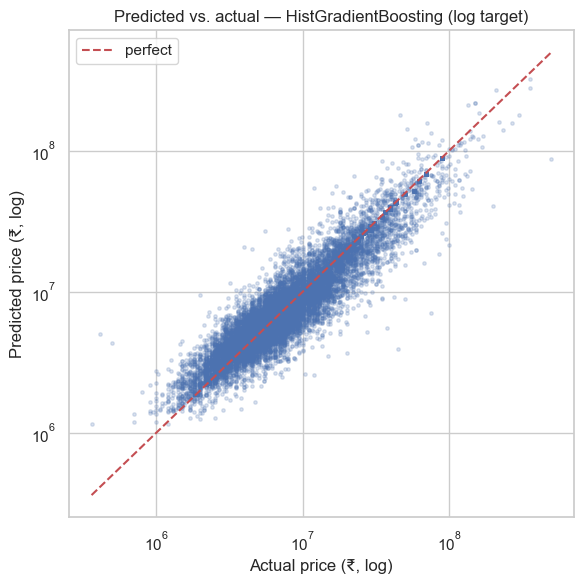

In [20]:
best_name = results.iloc[0]["Model"]
best_model = fitted[best_name]
pred_best = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred_best, s=6, alpha=0.2)
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, "r--", lw=1.5, label="perfect")
ax.set(xscale="log", yscale="log", xlabel="Actual price (₹, log)",
       ylabel="Predicted price (₹, log)", title=f"Predicted vs. actual — {best_name}")
ax.legend(); plt.tight_layout(); plt.show()

### Bonus — 5-fold cross-validation (with a data-ordering gotcha)

⚠ The CSV is **sorted into contiguous blocks by location**. A plain `cv=5` uses *un-shuffled* KFold,
which holds out entire cities the model never saw in training — collapsing the score to ~0.46 and
badly understating the model. We use **`KFold(shuffle=True)`** so each fold sees all cities, matching
our shuffled train/test split.


In [21]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=kf, scoring="r2", n_jobs=-1)
print(f"{best_name}")
print(f"Shuffled 5-fold CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print("Per-fold:", np.round(cv_scores, 3))

HistGradientBoosting (log target)
Shuffled 5-fold CV R²: 0.858 ± 0.023
Per-fold: [0.874 0.871 0.881 0.843 0.82 ]


### Winner & justification

**HistGradientBoosting (log target)** is our chosen model. It ties the RandomForest for the best test
accuracy (**R² ≈ 0.875, MAE ≈ ₹12 Lac ≈ 16% of the ₹79 Lac median price**) and its cross-validation is
stable (**R² ≈ 0.86 ± 0.02**), while the linear baseline reaches only R² ≈ 0.63 — confirming the
relationship is strongly non-linear.

Crucially, HistGradientBoosting is the best **deployable** choice: its pickle is **~1.8 MB**, versus
**~130 MB** for the RandomForest of comparable accuracy. That keeps the model comfortably under the
50 MB limit for committing to Git, trains in ~10 s, and predicts fast — so we export it as the product model.


## 2.6 Export the Model

We export the full pipeline (preprocessing + model) so the backend just calls `.predict()` on a raw
one-row DataFrame. We also save the location list for the frontend dropdown, and record the
scikit-learn version — a pickle only reloads reliably under the same version.


In [22]:
import json, sklearn

joblib.dump(best_model, "house_price.pkl")
print("Saved house_price.pkl  (", round(os.path.getsize("house_price.pkl") / 1e6, 2), "MB )")

locations = sorted(clean["location_grouped"].unique().tolist())
with open("locations.json", "w") as f:
    json.dump(locations, f, indent=2)
print("Saved locations.json  (", len(locations), "locations )")

# Save the exact input schema the backend must reproduce.
schema = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "categorical_options": {c: sorted(clean[c].dropna().unique().tolist())
                            for c in categorical_features},
    "sklearn_version": sklearn.__version__,
}
with open("model_columns.json", "w") as f:
    json.dump(schema, f, indent=2)
print("scikit-learn version (pin this in backend/requirements.txt):", sklearn.__version__)

Saved house_price.pkl  ( 1.84 MB )
Saved locations.json  ( 51 locations )


scikit-learn version (pin this in backend/requirements.txt): 1.6.1


In [23]:
# Sanity check: reload and predict one held-out sample.
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
pred_price = loaded.predict(sample)[0]
print("Sample features:")
display(sample.T)
print(f"Reloaded prediction: ₹{pred_price:,.0f}   |   actual: ₹{y_test.iloc[0]:,.0f}")

Sample features:


,183788
area_sqft,1050.0
floor_num,1.0
bathroom,NaN
balcony,1.0
car_parking,NaN
bhk,2.0
location_grouped,vijayawada
Furnishing,Semi-Furnished
Transaction,Resale
Ownership,NaN


Reloaded prediction: ₹3,731,157   |   actual: ₹4,000,000


### Outputs produced

- **`house_price.pkl`** — full preprocessing + HistGradientBoosting pipeline (served by the backend).
- **`locations.json`** — allowed locations for the frontend dropdown.
- **`model_columns.json`** — exact input schema + categorical options + scikit-learn version.

These are copied into `backend/models/` and the frontend so the app predicts on unseen input end-to-end.
